load your cleaned dataset

In [58]:
import pandas as pd
import numpy as np

In [59]:
df = pd.read_csv(r"C:\Users\Ajvad\Desktop\5th sem ojt\project 1_diabaties\data\processed\project1_diabetes_clean.csv",parse_dates=['last_checkup_date'])

In [60]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [61]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

In [62]:
df.shape

(950, 14)

create an age-band feature

In [63]:
df['age_band'] = pd.cut( df['age'], bins=[0, 35, 55, 120] , labels=('Youth','Middle-Aged','Senior'))

In [64]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,Senior
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,Middle-Aged
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,Middle-Aged
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,Senior
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,Senior
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0,Middle-Aged
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0,Senior
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1,Senior
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1,Youth
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1,Senior


In [65]:
df['age_band'].value_counts()

age_band
Senior         372
Middle-Aged    326
Youth          252
Name: count, dtype: int64

create a BMI category feature

In [66]:
df['bmi_category'] = pd.cut( df['bmi'], bins=[0, 18.5, 25, 30, 120] , labels=('Under-weight ','Normal','Over-weight','Obese'))

In [67]:
df['bmi_category'].value_counts()

bmi_category
Obese            553
Over-weight      235
Normal           124
Under-weight      38
Name: count, dtype: int64

create a glucose band features 

In [68]:
df['glucose_band'] = pd.cut( df['glucose'], bins=[0, 100, 126, 300,] , labels=('Normal ','Prediabetic','Diabetic'))

check glucose band distribution

In [69]:
df['glucose_band'].value_counts()

glucose_band
Diabetic       349
Prediabetic    337
Normal         264
Name: count, dtype: int64

create an insulin to glucose ratio feature 

In [70]:
df['insulin_glucose'] = df['insulin']/df['glucose']

In [71]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,Senior,Normal,Prediabetic,1.000000
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,Middle-Aged,Obese,Diabetic,0.274510
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,Middle-Aged,Over-weight,Diabetic,1.119718
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,Senior,Over-weight,Prediabetic,1.024793
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,Senior,Normal,Prediabetic,0.943925
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0,Middle-Aged,Normal,Diabetic,0.855172
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0,Senior,Over-weight,Normal,1.789474
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1,Senior,Obese,Diabetic,0.826667
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1,Youth,Normal,Diabetic,1.751938
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1,Senior,Obese,Diabetic,1.248447


check if there is any imposible value in the ratio

In [72]:
df['insulin_glucose'].describe()

count    950.000000
mean       1.213108
std        1.179183
min        0.054348
25%        0.726708
50%        1.052139
75%        1.512831
max       22.745763
Name: insulin_glucose, dtype: float64

In [73]:
# np.isinf is used check for infinite value 
np.isinf(df['insulin_glucose']).sum()

np.int64(0)

create a pregnencies-per-year-of-age feature

In [74]:
df['pregnancies_rate'] = df['pregnancies']/df['age']

In [75]:
df['pregnancies_rate'].head(10)

0    0.000000
1    0.000000
2    0.000000
3    0.102941
4    0.000000
5    0.000000
6    0.086207
7    0.051724
8    0.187500
9    0.000000
Name: pregnancies_rate, dtype: float64

In [76]:
df['pregnancies_rate'].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancies_rate, dtype: float64

create a days-since lastcheckup date feature

In [77]:
reference_date = df['last_checkup_date'].max()

In [78]:
reference_date

Timestamp('2024-12-28 00:00:00')

In [79]:
df['since_checkup'] = (reference_date - df['last_checkup_date']).dt.days

In [80]:
df['since_checkup'].head(10)

0    618
1    239
2    539
3    258
4    336
5    353
6    369
7    191
8    440
9    372
Name: since_checkup, dtype: int64

create a categorical combination feature

In [81]:
df['activity_smoker'] = df['physical_activity'] + '/' + df['smoker']

In [82]:
df['activity_smoker'].head(10)

0      Unknown/NO
1      Medium/YES
2     Low/UNKNOWN
3     Unknown/YES
4          Low/NO
5        High/YES
6         High/NO
7       Medium/NO
8    High/UNKNOWN
9      Medium/YES
Name: activity_smoker, dtype: str

check thr combination features balance 

In [83]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO          207
High/NO            195
Low/NO             180
Low/YES             93
Medium/YES          90
High/YES            85
Unknown/NO          36
High/UNKNOWN        22
Unknown/YES         17
Medium/UNKNOWN      12
Low/UNKNOWN          9
Unknown/UNKNOWN      4
Name: count, dtype: int64

list every new inventory column 

In [84]:
# activity_smoker = physical + smoker 
# since_checkup = reference - last_checkup_date
# pregnancies_rate = pregnency/age
# insulin_glucose = insulin/glucose
# glucose_band = glucose
# bmi_category = bmi
# age_band = age 

In [85]:
df.shape

(950, 21)

# Exploratory Analysis

re-run the group comparison on original features

In [86]:
numeric_cols = ['age','pregnancies','glucose','blood_pressure' ,'skin_thickness','insulin', 'bmi','diabetes_pedigree']
df.groupby('outcome')[numeric_cols].mean()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,,
0,47.874446,1.828656,112.220027,72.350074,26.370753,131.490399,30.941359,0.441821
1,54.798535,1.915751,131.868081,71.930403,26.047619,132.388278,32.516850,0.511564


In [87]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose,pregnancies_rate,since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,Senior,Normal,Prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,Middle-Aged,Obese,Diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,Middle-Aged,Over-weight,Diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,Senior,Over-weight,Prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,Senior,Normal,Prediabetic,0.943925,0.000000,336,Low/NO


In [88]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
age_band                   category
bmi_category               category
glucose_band               category
insulin_glucose             float64
pregnancies_rate            float64
since_checkup                 int64
activity_smoker                 str
dtype: object

run the same comparison on your engineered numeric features

In [89]:
engineered_numeric = ['pregnancies_rate','since_checkup','insulin_glucose']
df.groupby('outcome')[engineered_numeric].mean()

,pregnancies_rate,since_checkup,insulin_glucose
outcome,,,
0,0.044392,350.304284,1.271066
1,0.038809,366.534799,1.069380


rank everything together

In [90]:
#T=transporse-swapping row and column , abs()=absolute-make sure it only give positive value 
group_means = df.groupby('outcome')[numeric_cols + engineered_numeric].mean().T
group_means['gaps'] = (group_means[1] - group_means[0]).abs()
group_means.sort_values('gaps', ascending = False)

outcome,0,1,gaps
glucose,112.220027,131.868081,19.648054
since_checkup,350.304284,366.534799,16.230515
age,47.874446,54.798535,6.924089
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose,1.271066,1.069380,0.201686
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743


state the new top three

In [91]:
# 1-glucose
# 2-since_checkup
# 3-age

cross tabulate the age band against outcome 

In [92]:
pd.crosstab(df['age_band'],df['outcome'],normalize ='index')

outcome,0,1
age_band,,
Youth,0.789683,0.210317
Middle-Aged,0.766871,0.233129
Senior,0.612903,0.387097


cross tabulate the bmi against outcome

In [93]:
pd.crosstab(df['bmi_category'],df['outcome'],normalize ='index')

outcome,0,1
bmi_category,,
Under-weight,0.763158,0.236842
Normal,0.750000,0.250000
Over-weight,0.770213,0.229787
Obese,0.676311,0.323689


cross tabulate the glucose against outcome

In [94]:
pd.crosstab(df['glucose_band'],df['outcome'],normalize ='index')

outcome,0,1
glucose_band,,
Normal,0.901515,0.098485
Prediabetic,0.715134,0.284866
Diabetic,0.567335,0.432665


chart the clearest pattern


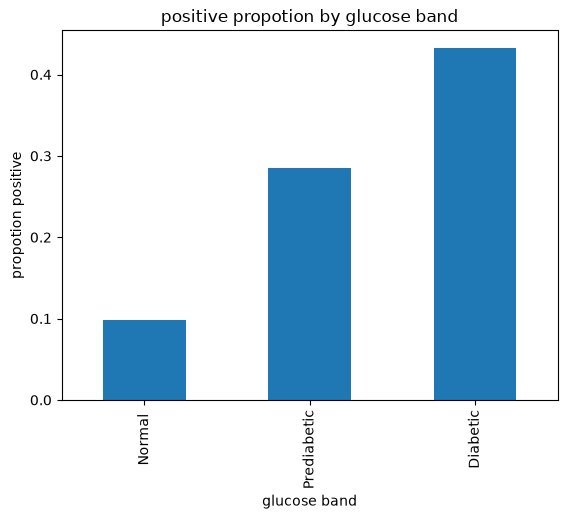

In [95]:
import matplotlib.pyplot as plt 

ax = pd.crosstab(df['glucose_band'],df['outcome'],normalize ='index')[1].plot(kind = 'bar')
ax.set_xlabel("glucose band")
ax.set_ylabel("propotion positive")
ax.set_title("positive propotion by glucose band")
plt.show()

In [96]:
df.to_csv(r"C:\Users\Ajvad\Desktop\5th sem ojt\project 1_diabaties\data\processed\muhammed_ajvad_sinan_p1w2_features.csv", index=False)

In [97]:
df = pd.read_csv(r"C:\Users\Ajvad\Desktop\5th sem ojt\project 1_diabaties\data\processed\muhammed_ajvad_sinan_p1w2_features.csv")

In [98]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose,pregnancies_rate,since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,Senior,Normal,Prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,Middle-Aged,Obese,Diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,Middle-Aged,Over-weight,Diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,Senior,Over-weight,Prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,Senior,Normal,Prediabetic,0.943925,0.000000,336,Low/NO
